# House Price Prediction

## Goal

Predict house prices using Machine Learning Regression.

Dataset:
- Tehran House Price Dataset

Tech Stack:
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-Learn

# 1. Import Libraries

In [593]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.model_selection import GridSearchCV
import joblib

# 2. Load Dataset


In [594]:
df=pd.read_csv('../data/housePrice.csv')

# 3. Initial Data Exploration

In [595]:
df.head(2)

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67


In [596]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   object 
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Address     3456 non-null   object 
 6   Price       3479 non-null   float64
 7   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(2), int64(1), object(2)
memory usage: 146.2+ KB


# 4. Clean And Transform Data

In [597]:
area_num_df=df.copy()

In [598]:
area_num_df['Area']=pd.to_numeric(area_num_df['Area'],errors='coerce')

In [599]:
not_valid_area=area_num_df[area_num_df['Area'].isna()].index.tolist()

In [600]:
df.loc[not_valid_area]

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
570,"3,310,000,000",2,True,True,True,Ostad Moein,3.310000e+09,110333.33
709,"16,160,000,000",3,True,True,True,Pasdaran,1.616000e+10,538666.67
807,"1,000",2,True,True,False,Damavand,7.000000e+09,233333.33
1604,"8,400,000,000",2,True,True,True,Gheitarieh,8.700000e+09,290000.00
2171,"3,600",2,False,False,False,Shahryar,9.720000e+09,324000.00
2802,"2,550,000,000",2,True,True,True,Central Janatabad,2.550000e+09,85000.00


In [601]:
df.columns

Index(['Area', 'Room', 'Parking', 'Warehouse', 'Elevator', 'Address', 'Price',
       'Price(USD)'],
      dtype='object')

In [602]:
clean_df=area_num_df.dropna()[['Area','Room','Parking','Warehouse','Elevator','Address','Price(USD)']]

In [603]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3450 entries, 0 to 3478
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3450 non-null   float64
 1   Room        3450 non-null   int64  
 2   Parking     3450 non-null   bool   
 3   Warehouse   3450 non-null   bool   
 4   Elevator    3450 non-null   bool   
 5   Address     3450 non-null   object 
 6   Price(USD)  3450 non-null   float64
dtypes: bool(3), float64(2), int64(1), object(1)
memory usage: 144.9+ KB


In [604]:
clean_df['Parking']=df["Parking"].astype(int)
clean_df['Warehouse']=df["Warehouse"].astype(int)
clean_df['Elevator']=df["Elevator"].astype(int)
clean_df.head(2)

,Area,Room,Parking,Warehouse,Elevator,Address,Price(USD)
0,63.0,1,1,1,1,Shahran,61666.67
1,60.0,1,1,1,1,Shahran,61666.67


In [605]:
# Duplicate records were removed before model training
duplicates=clean_df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
clean_df=clean_df.drop_duplicates()

Duplicate rows: 208


In [606]:
clean_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,3242.0,107.701110,70.935755,30.0,70.00,90.0,121.0000,929.0
Room,3242.0,2.087909,0.765248,0.0,2.00,2.0,2.0000,5.0
Parking,3242.0,0.845157,0.361810,0.0,1.00,1.0,1.0000,1.0
Warehouse,3242.0,0.914250,0.280037,0.0,1.00,1.0,1.0000,1.0
Elevator,3242.0,0.785626,0.410451,0.0,1.00,1.0,1.0000,1.0
Price(USD),3242.0,182454.112727,275753.904487,120.0,47333.33,99000.0,205249.9975,3080000.0


In [607]:
(clean_df[['Area','Room','Parking','Warehouse','Elevator','Price(USD)']].corr(method='pearson')
.drop('Price(USD)')[['Price(USD)']])

,Price(USD)
Area,0.720935
Room,0.569738
Parking,0.193761
Warehouse,0.109370
Elevator,0.110310


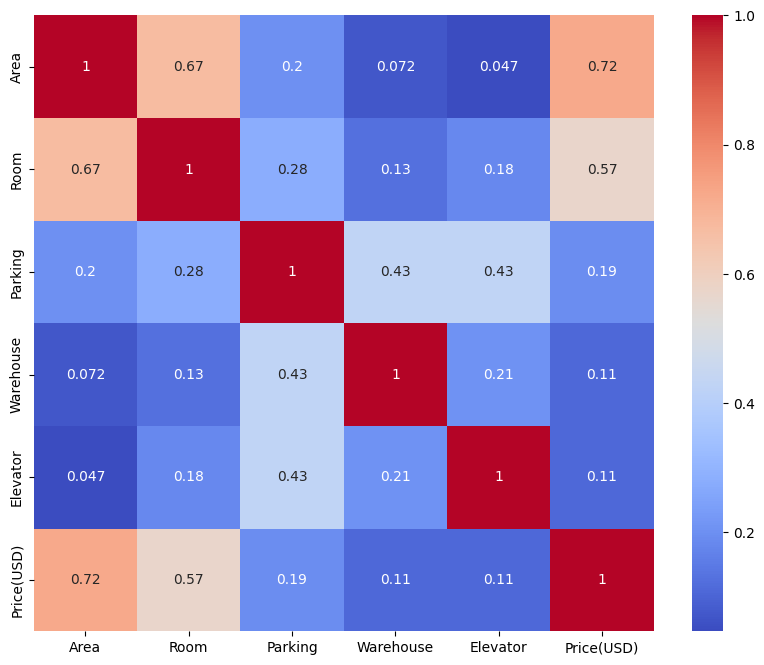

In [667]:
plt.figure(figsize=(10,8))
sns.heatmap(clean_df[['Area','Room','Parking','Warehouse','Elevator','Price(USD)']].corr(method='pearson'),annot=True,
            cmap="coolwarm")
plt.savefig("../images/heatmap_.png")
plt.show()

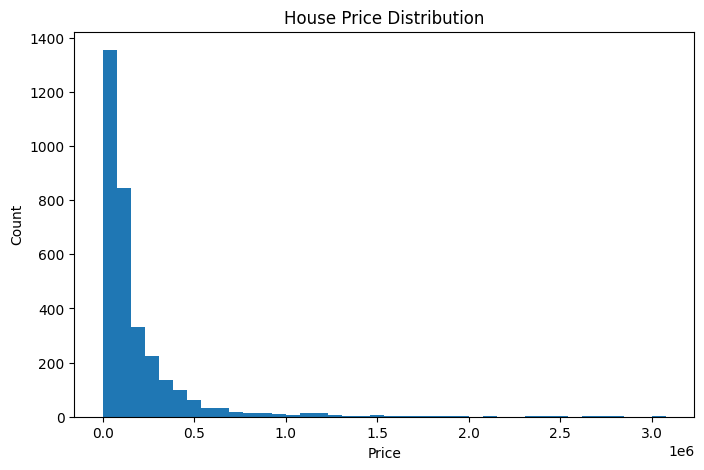

In [660]:
plt.figure(figsize=(8,5))
plt.hist(clean_df['Price(USD)'],bins=40)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.savefig("../images/house_price_distribution.png")
plt.show()

In [610]:
clean_df["Price_log"]=np.log1p(clean_df['Price(USD)'])
clean_df.head(2)

,Area,Room,Parking,Warehouse,Elevator,Address,Price(USD),Price_log
0,63.0,1,1,1,1,Shahran,61666.67,11.029515
1,60.0,1,1,1,1,Shahran,61666.67,11.029515


# 5. Split Data

In [611]:
X_train,X_test,y_train,y_test=train_test_split(clean_df[['Area','Room','Parking','Address']],
                                              clean_df['Price_log'],test_size=0.2,random_state=42)

# 6. Address Encoding

In [612]:
train_df=X_train
train_df['Price']=y_train
train_df.head(3)

,Area,Room,Parking,Address,Price
3139,61.0,1,0,Ostad Moein,10.579853
890,105.0,3,1,East Ferdows Boulevard,11.775297
1252,179.0,3,1,Pasdaran,12.680756


In [613]:
# Compute global mean for target encoding
global_mean=y_train.mean()

In [614]:
address_encoding=train_df.groupby("Address")["Price"].agg(['count','mean'])
address_encoding.head()

,count,mean
Address,,
Abazar,23,12.068927
Abbasabad,1,11.800615
Absard,5,11.801444
Abuzar,2,10.923631
Afsarieh,6,10.974399


In [615]:
k=10
address_encoding["smoothing"]=((address_encoding['count']*address_encoding['mean'])+(k*global_mean))/(k+address_encoding['count'])

In [616]:
address_encoding.head()

,count,mean,smoothing
Address,,,
Abazar,23,12.068927,11.884891
Abbasabad,1,11.800615,11.492425
Absard,5,11.801444,11.574886
Abuzar,2,10.923631,11.371944
Afsarieh,6,10.974399,11.278904


In [617]:
smoothing_map=address_encoding['smoothing'].to_dict()
smoothing_map["global_mean"]=global_mean

In [618]:
train_df["Address_num"]=train_df["Address"].map(smoothing_map)

In [619]:
train_df=train_df.drop("Price", axis=1)
train_df.head()

,Area,Room,Parking,Address,Address_num
3139,61.0,1,0,Ostad Moein,11.041760
890,105.0,3,1,East Ferdows Boulevard,11.558016
1252,179.0,3,1,Pasdaran,12.338847
2455,105.0,2,1,Kahrizak,10.848496
2839,48.0,1,1,Jeyhoon,10.898823


In [620]:
test_df=X_test
test_df["Address_num"]=test_df["Address"].map(smoothing_map).fillna(global_mean)
test_df.head()

,Area,Room,Parking,Address,Address_num
3094,84.0,2,1,Shahran,11.473331
1361,133.0,3,1,East Ferdows Boulevard,11.558016
2254,120.0,3,1,Yousef Abad,12.067602
333,55.0,1,1,Shahr-e-Ziba,11.507096
3472,113.0,3,1,Ostad Moein,11.041760


In [621]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 649 entries, 3094 to 3386
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         649 non-null    float64
 1   Room         649 non-null    int64  
 2   Parking      649 non-null    int64  
 3   Address      649 non-null    object 
 4   Address_num  649 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 30.4+ KB


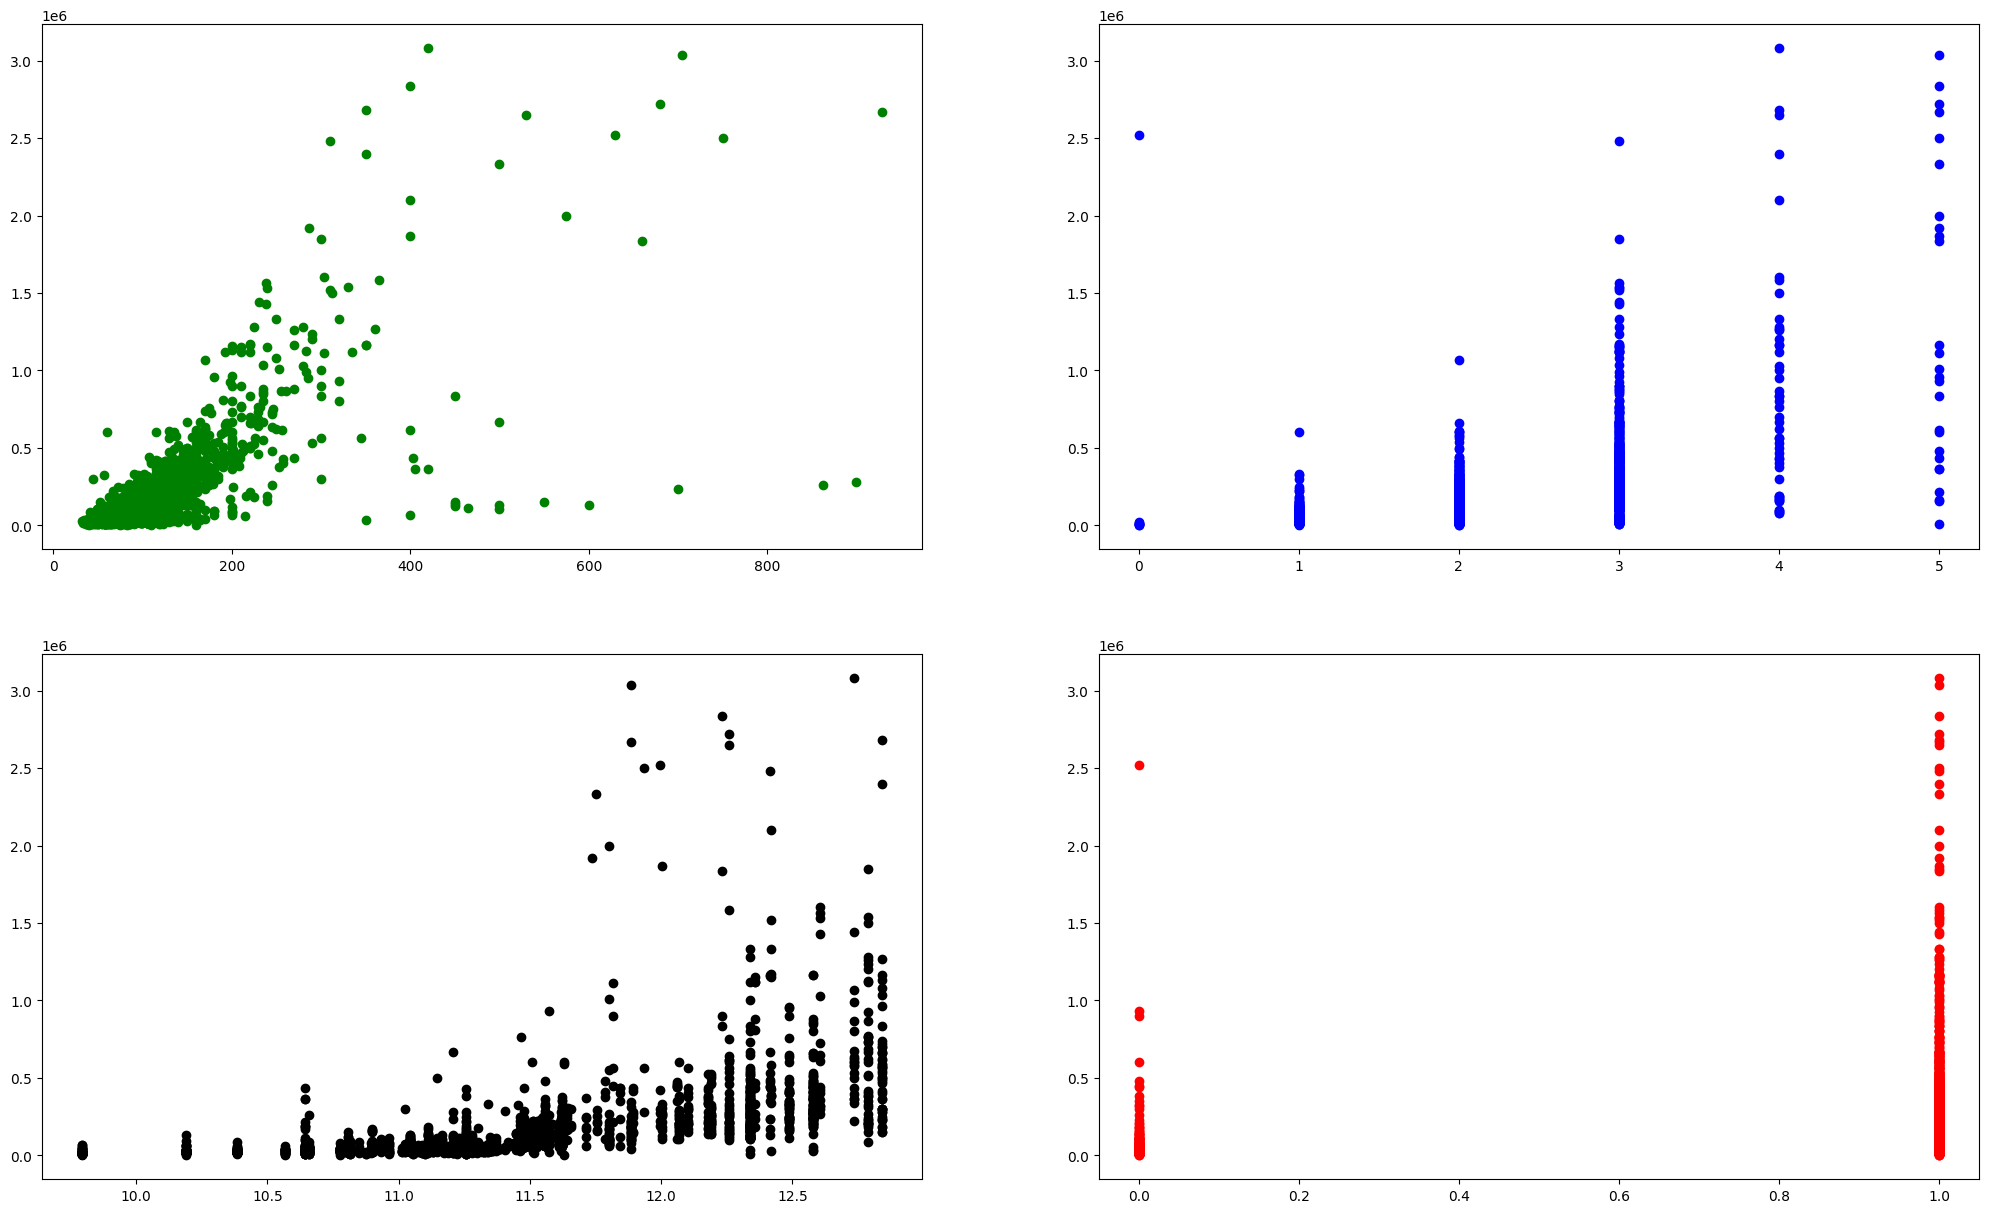

In [622]:
figure,subplot=plt.subplots(2,2,figsize=(25,15))
subplot[0][0].scatter(train_df["Area"],np.expm1(y_train),color="g")
subplot[0][1].scatter(train_df["Room"],np.expm1(y_train),color="b")
subplot[1][0].scatter(train_df["Address_num"],np.expm1(y_train),color="black")
subplot[1][1].scatter(train_df["Parking"],np.expm1(y_train),color="r")
plt.show()

In [623]:
train_df.columns

Index(['Area', 'Room', 'Parking', 'Address', 'Address_num'], dtype='object')

# 7. Normalization

In [624]:
sc=StandardScaler()
X_train_s=sc.fit_transform(train_df[['Area', 'Room', 'Parking','Address_num']])
X_test_s=sc.transform(test_df[['Area', 'Room', 'Parking','Address_num']])
area_train=np.reshape(X_train_s[ : ,0],shape=(len(X_train_s), 1))
area_test=np.reshape(X_test_s[ : ,0],shape=(len(X_test_s), 1))

In [625]:
y_train=np.asanyarray(y_train)
y_test=np.asanyarray(y_test)

# 8. Model Training

# 8-1.Linear Regression

In [626]:
# simple model just train with Area feature
regr=linear_model.LinearRegression()
simple_regr=linear_model.LinearRegression()
regr.fit(X_train_s,y_train)
simple_regr.fit(area_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [627]:
y_hat_l=regr.predict(X_test_s)
y_simple_hat=simple_regr.predict(area_test)

In [628]:
l_r2_train=r2_score(y_train,regr.predict(X_train_s))
l_r2=r2_score(y_test,y_hat_l)
l_mse=mean_squared_error(y_test,y_hat_l)
l_mae=mean_absolute_error(y_test,y_hat_l)
print("mulitple R2 score on train is %.5f"%l_r2_train)
print("mulitple R2 score on test is %.5f"%l_r2)
print("mulitple MSE on test is %.5f"%l_mse)
print("mulitple MAE on test is %.5f"%l_mae)

mulitple R2 score on train is 0.83361
mulitple R2 score on test is 0.86176
mulitple MSE on test is 0.16861
mulitple MAE on test is 0.28405


In [629]:
print("simple R2 score is %.5f"%r2_score(y_test,y_simple_hat))
print("simple MSE is %.5f"%mean_squared_error(y_test,y_simple_hat))
print("simple MAE is %.5f"%mean_absolute_error(y_test,y_simple_hat))

simple R2 score is 0.34381
simple MSE is 0.80036
simple MAE is 0.68996


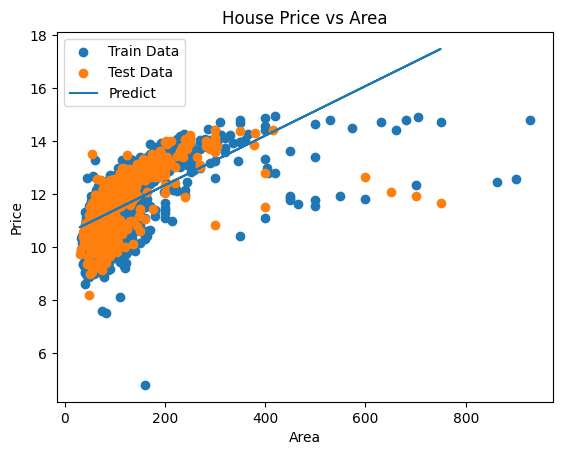

In [630]:
plt.scatter(sc.inverse_transform(X_train_s)[:,0],y_train,label="Train Data")
x=sc.inverse_transform(X_test_s)[:,0]
plt.scatter(x,y_test,label="Test Data")
plt.plot(x,y_simple_hat,label="Predict")
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("House Price vs Area")
plt.legend()
plt.show()

# 8-2.Polynomial Regression

In [631]:
x_train=np.c_[X_train_s[:,0],X_train_s[:,0]**2,X_train_s[:,0]**3,X_train_s[:,3],X_train_s[:,1]**2,
X_train_s[:,1]**3,X_train_s[:,2],X_train_s[:,0]*X_train_s[:,1],X_train_s[:,1]*X_train_s[:,2]]
regr=linear_model.LinearRegression()
regr.fit(x_train,y_train)
x_test=np.c_[X_test_s[:,0],X_test_s[:,0]**2,X_test_s[:,0]**3,X_test_s[:,3],X_test_s[:,1]**2,
X_test_s[:,1]**3,X_test_s[:,2],X_test_s[:,0]*X_test_s[:,1],X_test_s[:,1]*X_test_s[:,2]]
y_hat=regr.predict(x_test)
print(f'Train R2 score:{r2_score(y_train,regr.predict(x_train))}')
print(f'Test R2 score {r2_score(y_test,y_hat)}')
print(f'MSE :{mean_squared_error(y_test,y_hat)}')
print(f'MAE :{mean_absolute_error(y_test,y_hat)}')

Train R2 score:0.84831368326694
Test R2 score 0.8864344623308746
MSE :0.13851547093597918
MAE :0.2562868817092373


In [632]:
poly=PolynomialFeatures(degree=3)
x_train=poly.fit_transform(X_train_s)
regr=linear_model.LinearRegression()
regr.fit(x_train,y_train)
x_test=poly.fit_transform(X_test_s)
y_hat_p=regr.predict(x_test)
p_r2_train=r2_score(y_train,regr.predict(x_train))
p_r2=r2_score(y_test,y_hat_p)
p_mse=mean_squared_error(y_test,y_hat_p)
p_mae=mean_absolute_error(y_test,y_hat_p)
print(f'Train R2 score:{p_r2_train}')
print(f'Test R2 score {p_r2}')
print(f'MSE :{p_mse}')
print(f'MAE :{p_mae}')

Train R2 score:0.8650828011982687
Test R2 score 0.8884624468395256
MSE :0.13604194564800778
MAE :0.24481819556663678


# 8-3.Random Forest

In [633]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_s, y_train)
y_hat_rf = rf.predict(X_test_s)
rf_r2_train=r2_score(y_train,rf.predict(X_train_s))
rf_r2=r2_score(y_test,y_hat_rf)
rf_mse=mean_squared_error(y_test,y_hat_rf)
rf_mae=mean_absolute_error(y_test,y_hat_rf)
print(f'Train R2 score:{rf_r2_train}')
print(f'Test R2 score {rf_r2}')
print(f'MSE :{rf_mse}')
print(f'MAE :{rf_mae}')

Train R2 score:0.9708843047824466
Test R2 score 0.8992572146995728
MSE :0.12287560677031577
MAE :0.22849757322885794


# 8-4.Gradient Boosting

In [634]:
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train_s, y_train)
y_hat_gbr = rf.predict(X_test_s)
gbr_r2_train=r2_score(y_train,gbr.predict(X_train_s))
gbr_r2=r2_score(y_test,y_hat_gbr)
gbr_mse=mean_squared_error(y_test,y_hat_gbr)
gbr_mae=mean_absolute_error(y_test,y_hat_gbr)
print(f'Train R2 score:{gbr_r2_train}')
print(f'Test R2 score {gbr_r2}')
print(f'MSE :{gbr_mse}')
print(f'MAE :{gbr_mae}')

Train R2 score:0.9114128455094035
Test R2 score 0.8992572146995728
MSE :0.12287560677031577
MAE :0.22849757322885794


# 9. Comparison of models

In [635]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Polynomial Regression",
        "Random Forest",
        "Gradient Boosting"],
    "Test MAE":[l_mae,p_mae,rf_mae,gbr_mae],
    "Test MSE":[l_mse,p_mse,rf_mse,gbr_mse],
    "Test R2":[l_r2,p_r2,rf_r2,gbr_r2],
    "Train R2":[l_r2_train,p_r2_train,rf_r2_train,gbr_r2_train]
})
results

,Model,Test MAE,Test MSE,Test R2,Train R2
0,Linear Regression,0.284051,0.168607,0.861764,0.833609
1,Polynomial Regression,0.244818,0.136042,0.888462,0.865083
2,Random Forest,0.228498,0.122876,0.899257,0.970884
3,Gradient Boosting,0.228498,0.122876,0.899257,0.911413


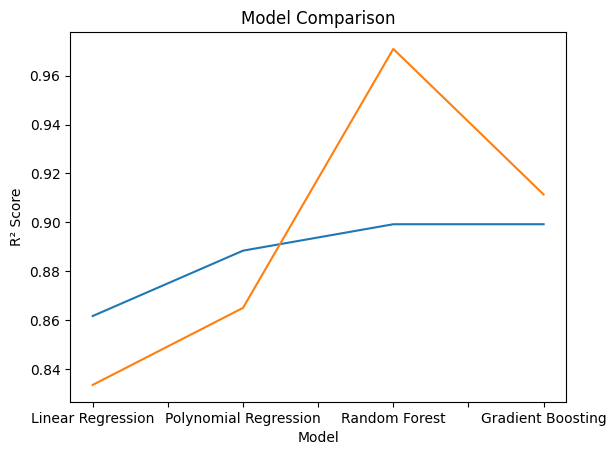

In [636]:
results.plot(x="Model",y=["Test R2","Train R2"],legend=False)
plt.ylabel("R² Score")
plt.title("Model Comparison")
plt.savefig("../images/model_comparison.png")
plt.show()

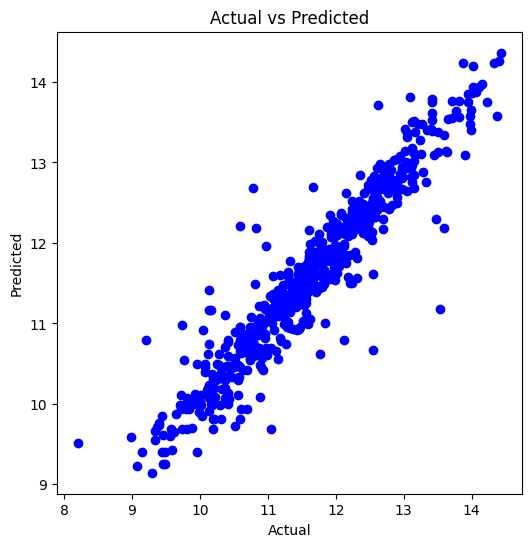

In [637]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_hat_rf,color='b')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.savefig("../images/actual_vs_predicted.png")
plt.show()

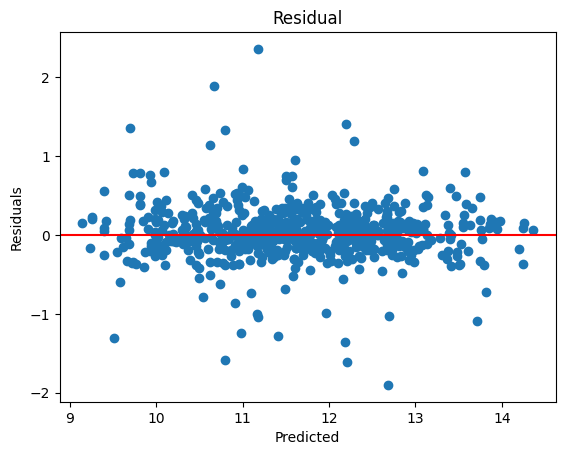

In [638]:
residuals = y_test - y_hat_rf
plt.scatter(y_hat_rf, residuals)
plt.axhline(0,color='r')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual")
plt.savefig("../images/residual.png")
plt.show()

# Conclusion

Several regression models were evaluated for predicting house prices, including Linear Regression, Polynomial Regression, Random Forest Regressor, and Gradient Boosting Regressor.

Among the evaluated models, both **Random Forest** and **Gradient Boosting** achieved very similar performance on the test set, producing nearly identical values for MAE, MSE, RMSE, and R². This indicates that both ensemble methods are highly effective for this dataset.

Although Random Forest obtained a slightly higher training R² score, its performance on unseen test data was not significantly better than Gradient Boosting. Therefore, based on the evaluation metrics, both models demonstrate strong generalization ability, while Gradient Boosting achieves comparable performance without relying on a higher training score.

Overall, ensemble tree-based models clearly outperformed the linear models, suggesting that the relationship between the input features and house prices is not purely linear.

# 10. Hyperparameter Tuning

In [639]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1)
grid_search.fit(X_train_s, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter cand

In [640]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
0.8697401678132788


In [641]:
best_rf = grid_search.best_estimator_
pred = best_rf.predict(X_test_s)
print(f'R2 score {r2_score(y_test,pred)}')
print(f'MSE :{mean_squared_error(y_test,pred)}')
print(f'MAE :{mean_absolute_error(y_test,pred)}')

R2 score 0.9055212904206583
MSE :0.11523533652378395
MAE :0.22155842985690244


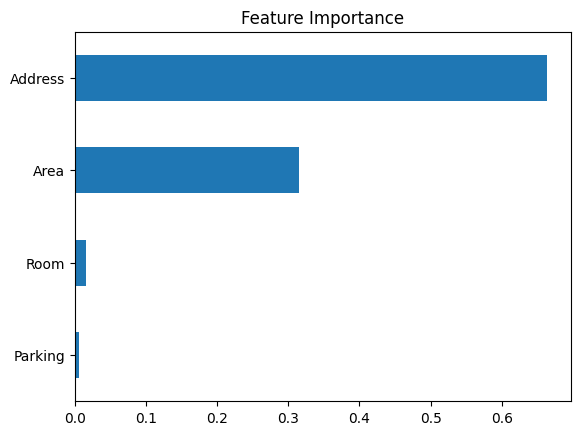

In [663]:
importance = pd.Series(best_rf.feature_importances_,index=['Area', 'Room', 'Parking', 'Address'])
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.savefig("../images/feature_importance.png")
plt.show()

The **Address** feature has the strongest influence on house price prediction, while other features contribute to a lesser extent.

# 11. Saveing
The final trained model and the fitted `StandardScaler` were saved using Joblib.

Since the selected model was trained on standardized features, the same scaler must be applied to any new input data before making predictions. This ensures consistency between the training and inference stages.

In [643]:
joblib.dump(best_rf, "../models/house_price_model.pkl")
joblib.dump(sc, "../models/scaler.pkl")
joblib.dump(smoothing_map, "../models/smoothing_map.pkl")

['../models/smoothing_map.pkl']